# Data Standardization and Scaling
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Comparing StandardScaler and MinMaxScaler, and why feature scale affects distance-based models.

### Main goals:

- Show why unscaled features distort distance calculations.
- Implement and compare StandardScaler and MinMaxScaler.
- Test how each scaler behaves in the presence of an outlier.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Feature Scale Comparison

In [2]:
df = pd.DataFrame({
    'age':     [25, 34, 45, 28, 52, 31],
    'income':  [50000, 82000, 120000, 45000, 95000, 60000],
    'risk_score': [0.21, 0.45, 0.62, 0.18, 0.71, 0.30]
})
for col in df.columns:
    print(f'{col:12s}: range = {df[col].max() - df[col].min():.2f}')

age         : range = 27.00
income      : range = 75000.00
risk_score  : range = 0.53


**Observation:**
income range is roughly 75000 vs risk_score range of 0.5 — five orders of magnitude apart before any distance is computed.

In [3]:
person_a = df.iloc[0][['age', 'income', 'risk_score']].values.astype(float)
person_b = df.iloc[1][['age', 'income', 'risk_score']].values.astype(float)

raw_distance = np.sqrt(np.sum((person_a - person_b) ** 2))
print(f'Raw distance: {raw_distance:.2f}')

contributions = (person_a - person_b) ** 2
for name, contrib in zip(['age', 'income', 'risk_score'], contributions):
    print(f'  {name:12s}: {contrib/contributions.sum()*100:5.1f}% of squared distance')

Raw distance: 32000.00
  age         :   0.0% of squared distance
  income      : 100.0% of squared distance
  risk_score  :   0.0% of squared distance


**Observation:**
income accounts for 100% of the squared distance, age and risk_score for 0%. Unscaled, a distance-based model is effectively blind to two of the three features.

## StandardScaler

In [4]:
scaler_standard = StandardScaler()
df_standard = pd.DataFrame(scaler_standard.fit_transform(df), columns=df.columns)
df_standard.round(3)

,age,income,risk_score
0,-1.131,-0.955,-1.007
1,-0.191,0.251,0.191
2,0.957,1.684,1.040
3,-0.818,-1.143,-1.157
4,1.687,0.741,1.490
5,-0.504,-0.578,-0.558


In [5]:
print(df_standard.mean().round(10))
print(df_standard.std(ddof=0).round(10))

age          -0.0
income        0.0
risk_score    0.0
dtype: float64
age           1.0
income        1.0
risk_score    1.0
dtype: float64


**Observation:**
pandas `.std()` defaults to `ddof=1`, so it does not verify to exactly 1.0 unless `ddof=0` is passed to match what StandardScaler uses internally.

In [6]:
person_a_scaled = df_standard.iloc[0].values
person_b_scaled = df_standard.iloc[1].values
scaled_contributions = (person_a_scaled - person_b_scaled) ** 2

for name, contrib in zip(['age', 'income', 'risk_score'], scaled_contributions):
    print(f'  {name:12s}: {contrib/scaled_contributions.sum()*100:5.1f}% of squared distance')

  age         :  23.4% of squared distance
  income      :  38.6% of squared distance
  risk_score  :  38.1% of squared distance


**Observation:**
After scaling, all three features contribute 30–40% of the distance instead of one feature taking all of it.

## MinMaxScaler

In [7]:
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df), columns=df.columns)
print('min:', df_minmax.min().values, '  max:', df_minmax.max().values)

min: [0. 0. 0.]   max: [1. 1. 1.]


## Scaler Comparison

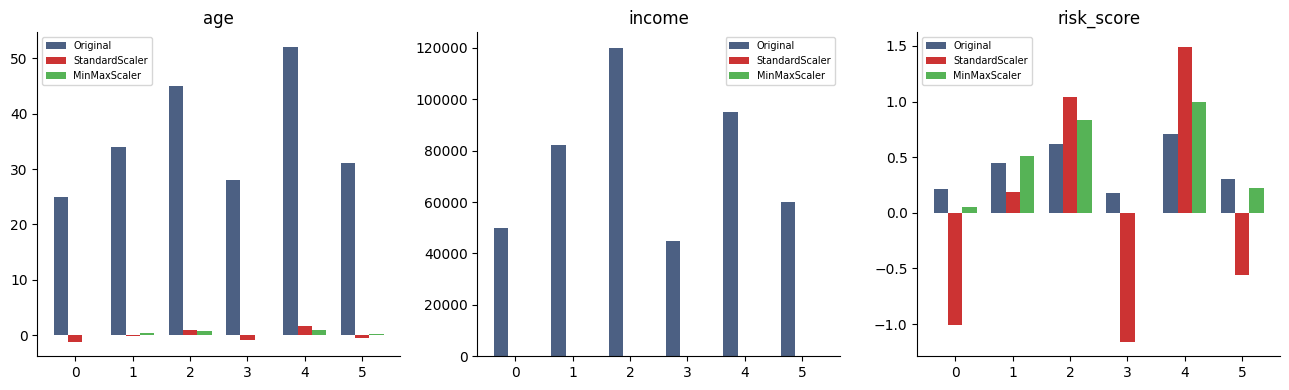

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
x = np.arange(len(df))
width = 0.25
for ax, col in zip(axes, df.columns):
    ax.bar(x - width, df[col], width, label='Original', color='#1F3864', alpha=0.8)
    ax.bar(x, df_standard[col], width, label='StandardScaler', color='#C00000', alpha=0.8)
    ax.bar(x + width, df_minmax[col], width, label='MinMaxScaler', color='#2CA02C', alpha=0.8)
    ax.set_title(col)
    ax.set_xticks(x)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Outlier Sensitivity

In [9]:
df_outlier = df.copy()
df_outlier.loc[len(df_outlier)] = [40, 5000000, 0.5]

scaled_standard_outlier = pd.DataFrame(StandardScaler().fit_transform(df_outlier), columns=df.columns)
scaled_minmax_outlier = pd.DataFrame(MinMaxScaler().fit_transform(df_outlier), columns=df.columns)

print('StandardScaler income:', scaled_standard_outlier['income'].round(2).values)
print('MinMaxScaler income:  ', scaled_minmax_outlier['income'].round(2).values)

StandardScaler income: [-0.42 -0.4  -0.38 -0.43 -0.4  -0.42  2.45]
MinMaxScaler income:   [0.   0.01 0.02 0.   0.01 0.   1.  ]


**Observation:**
MinMaxScaler compresses the rest of the data into 0–0.02 once one outlier reaches 1.0, leaving almost no spread between normal points. StandardScaler keeps the outlier visible but preserves usable spread for the rest of the data. MinMaxScaler turned out to be the more fragile option, the opposite of what was expected going in.